# Popular bands by British city: Spotify reach and population


> **CURRENT-DATA PREVIEW: Spotify metrics captured 17 July 2026.** This is a separate sensitivity run. The published notebook remains pinned to the September 2025 snapshot.

## 01. Research question

This notebook compares the Spotify reach of bands associated with ten British cities. The dataset contains a personal shortlist of 50 bands, five per city. It is an exploratory sample, not a complete catalogue of UK bands or cities.

The main question is whether the selected bands from some cities have unusually high Spotify reach relative to built-up-area population.

Within this shortlist, Sheffield ranks first when each city's top three eligible bands are measured by monthly listeners per resident. Sheffield, Liverpool and Manchester are the top three cities. A follower-based version produces a similar ordering; the rank correlation is 0.93, where 1.0 would mean identical ranks.


## 02. Scope and scoring

The shortlist covers named bands and groups; solo artists are excluded. It is weighted toward rock, indie, post-punk, new wave and related genres. The ten cities are in England and Scotland, so the sample does not represent the whole United Kingdom.

Each band is assigned to the built-up area where it formed or first became established. A built-up area is the continuously developed urban area around a city, rather than its administrative council boundary.

Monthly listeners approximate the number of unique Spotify users who listened to an artist during a rolling monthly window. Followers are Spotify users who chose to follow the artist. This notebook run uses the 17 July 2026 snapshot of both measures.

I compare the cities three ways:

- Raw total: combined monthly listeners across all five shortlisted bands.
- Leading-band share: the proportion of a city's eligible listeners attributable to its largest band.
- Preferred score: combined monthly listeners for the top three bands with at least 100,000 followers, divided by built-up-area population.


## 03. Data sources

The band shortlist and city assignments were created manually in the original project scratchpad. They reflect the initial selection used to test the idea.

Population figures are 2021 built-up-area counts from the Office for National Statistics and Scotland's 2021 Census. The original notebook compiled the figures through City Population. Spotify artist IDs were found through Spotify search. Followers and monthly listeners in this run came from Spotify's public artist pages on 17 July 2026.

A broader MusicBrainz catalogue has since been collected, but it is not used in this notebook.

The analysis reads saved local files and does not call live APIs. This keeps reruns reproducible.

### 03.01 Analysis setup

The setup cell imports the shared calculation and plotting functions. Custom styling is limited to the exported figures.


In [1]:
# Find the repository and import the reusable project code.
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "reference" / "original_shortlist.csv").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the python_uk_bands repository")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def display_path(path: Path) -> Path:
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


from python_uk_bands.analysis import (
    build_city_rankings,
    build_threshold_sensitivity,
)
from python_uk_bands.dataset import (
    build_match_review_queue,
    build_quality_summary,
    load_shortlist_dataset,
    validate_shortlist_shape,
)
from python_uk_bands.visuals import (
    apply_chart_style,
    plot_city_band_stack,
    plot_metric_rank_comparison,
    plot_overall_city_monthly_listeners,
    plot_population_rank_shift,
    plot_threshold_coverage,
    plot_top_bands_by_followers,
    plot_top_band_concentration,
    plot_top_three_ratio,
)

apply_chart_style()


### 03.02 Input files

The analysis joins three files:

- `reference/original_shortlist.csv`: 50 bands, five from each of ten cities.
- `reference/built_up_areas.csv`: 2021 population denominators for comparable urban areas.
- `data/processed/shortlist_spotify_metrics_20260717T225913Z.json`: Spotify IDs, followers and monthly listeners saved on 17 July 2026.

The joined dataset has one row per band with its city, Spotify measures and population denominator.


In [2]:
# Join the shortlist, Spotify metrics and population at one row per band.
METRICS_PATH = PROJECT_ROOT / 'data/processed/shortlist_spotify_metrics_20260717T225913Z.json'
CHART_OUTPUT_DIR = PROJECT_ROOT / 'artifacts/publication_previews/20260717T225913Z'
band_data = load_shortlist_dataset(metrics_path=METRICS_PATH)

preview_columns = [
    "band_name",
    "city",
    "followers",
    "monthly_listeners",
    "population",
    "stats_extracted_at",
]
display(band_data.loc[:, preview_columns].head())


,band_name,city,followers,monthly_listeners,population,stats_extracted_at
0,The Rolling Stones,London,16647224,30644916,9540576,2026-07-17
1,The Clash,London,3507296,14556602,9540576,2026-07-17
2,Blur,London,4273555,14051908,9540576,2026-07-17
3,Coldplay,London,64720341,91959876,9540576,2026-07-17
4,Florence and the Machine,London,7585878,25889479,9540576,2026-07-17


## 04. Data quality

The joined dataset should contain 50 unique bands, ten cities, five bands per city, one Spotify ID per band and no missing popularity or population values.

Spotify matches were selected automatically. An `exact` name match does not prove that the correct artist was selected. The review table includes non-exact matches and accounts with fewer than 100 followers. Dog Is Dead is a known incorrect match; it falls below the eligibility threshold and does not affect the preferred ranking.


In [3]:
# Check the expected shape and show anything that still needs human review.
validate_shortlist_shape(band_data)
quality_summary = build_quality_summary(band_data)
match_review_queue = build_match_review_queue(band_data)

display(quality_summary)
display(match_review_queue)


,check,result
0,Shortlist rows,50
1,Unique bands,50
2,Cities represented,10
3,Missing Spotify IDs,0
4,Missing populations,0
5,Missing popularity metrics,0
6,Duplicate Spotify IDs,0
7,Snapshot dates,1


,band_name,spotify_name,match_quality,followers,monthly_listeners
0,Dog Is Dead,Every 90's Dog is Dead,approximate,174,0
1,Florence and the Machine,Florence + The Machine,fallback,7585878,25889479


## 05. Assumptions and limitations

- A band belongs to the built-up area where it formed or first became established. Some current assignments still need editorial review.
- Dividing global Spotify reach by local population is a normalization device. It does not mean local residents generated those streams or follows.
- The follower threshold removes tiny or mismatched accounts, but it can also remove a real act with strong passive listening and a small follower base.
- Bands are not independent observations. Related acts can emerge from the same scene and share members.
- Spotify measures platform reach. It does not measure musical influence, record sales, live audiences or the health of a local scene.
- The 2021 population denominator and {facts['snapshot_long']} Spotify snapshot refer to different dates.


## 06. Unadjusted Spotify reach

The first comparison sums monthly listeners across all five shortlisted bands in each city. No follower threshold or population adjustment is applied. Every city contributes the same number of bands.


In [4]:
# Calculate raw and per-resident totals from the same 50 bands.
BANDS_PER_CITY = int(band_data.groupby("city").size().max())
all_band_city_rankings = build_city_rankings(
    band_data,
    metric="monthly_listeners",
    top_n=BANDS_PER_CITY,
)
all_band_rank_shift = all_band_city_rankings[["city", "total_value", "total_ratio"]].copy()
all_band_rank_shift["raw_rank"] = all_band_rank_shift["total_value"].rank(
    method="min", ascending=False
).astype(int)
all_band_rank_shift["population_adjusted_rank"] = all_band_rank_shift["total_ratio"].rank(
    method="min", ascending=False
).astype(int)

display(
    all_band_rank_shift.sort_values("raw_rank").rename(
        columns={
            "city": "City",
            "total_value": "Monthly listeners",
            "total_ratio": "Monthly listeners / resident",
            "raw_rank": "Raw rank",
            "population_adjusted_rank": "Adjusted rank",
        }
    )
)


,City,Monthly listeners,Monthly listeners / resident,Raw rank,Adjusted rank
5,London,177102781,18.563112,1,6
2,Manchester,92626004,32.298335,2,3
0,Sheffield,85695184,54.617708,3,1
4,Birmingham,62376134,23.922394,4,5
1,Liverpool,51268480,33.603471,5,2
6,Glasgow,26900505,16.076012,6,7
3,Bristol,18103278,25.417920,7,4
7,Leeds,17946736,9.429630,8,8
8,Bradford,11170866,8.095581,9,9
9,Nottingham,6559323,7.133700,10,10


### 06.01 City totals

London ranks first with 177.1 million combined monthly listeners. Manchester ranks second with 92.6 million. These totals measure the selected catalogues without accounting for city population.


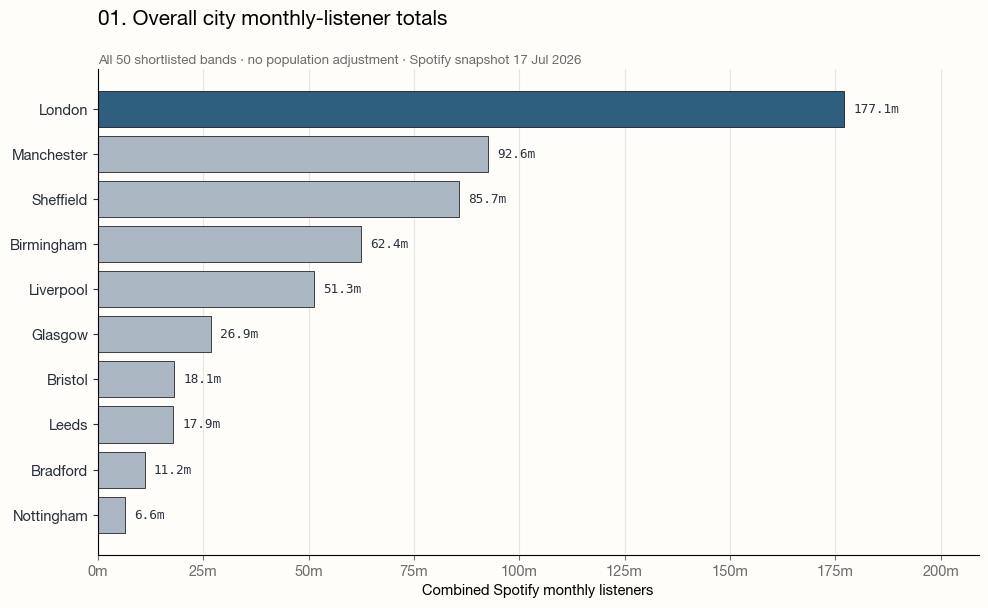

PosixPath('artifacts/publication_previews/20260717T225913Z/chart_01_overall_city_monthly_listeners.png')

In [5]:
# Plot the unadjusted city totals.
figure_01_path = plot_overall_city_monthly_listeners(
    all_band_city_rankings,
    snapshot_date=band_data["stats_extracted_at"].max().strftime("%d %b %Y"),
    shortlist_size=len(band_data),
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_01_path)


### 06.02 Band contributions to city totals

The stacked bars show how each of the five selected bands contributes to its city total. Coldplay accounts for the largest share of London's total. The Beatles dominate Liverpool. Manchester's total is distributed more evenly across Oasis, The Smiths, The 1975 and the remaining bands.

Segment numbers correspond to the band key on the right.


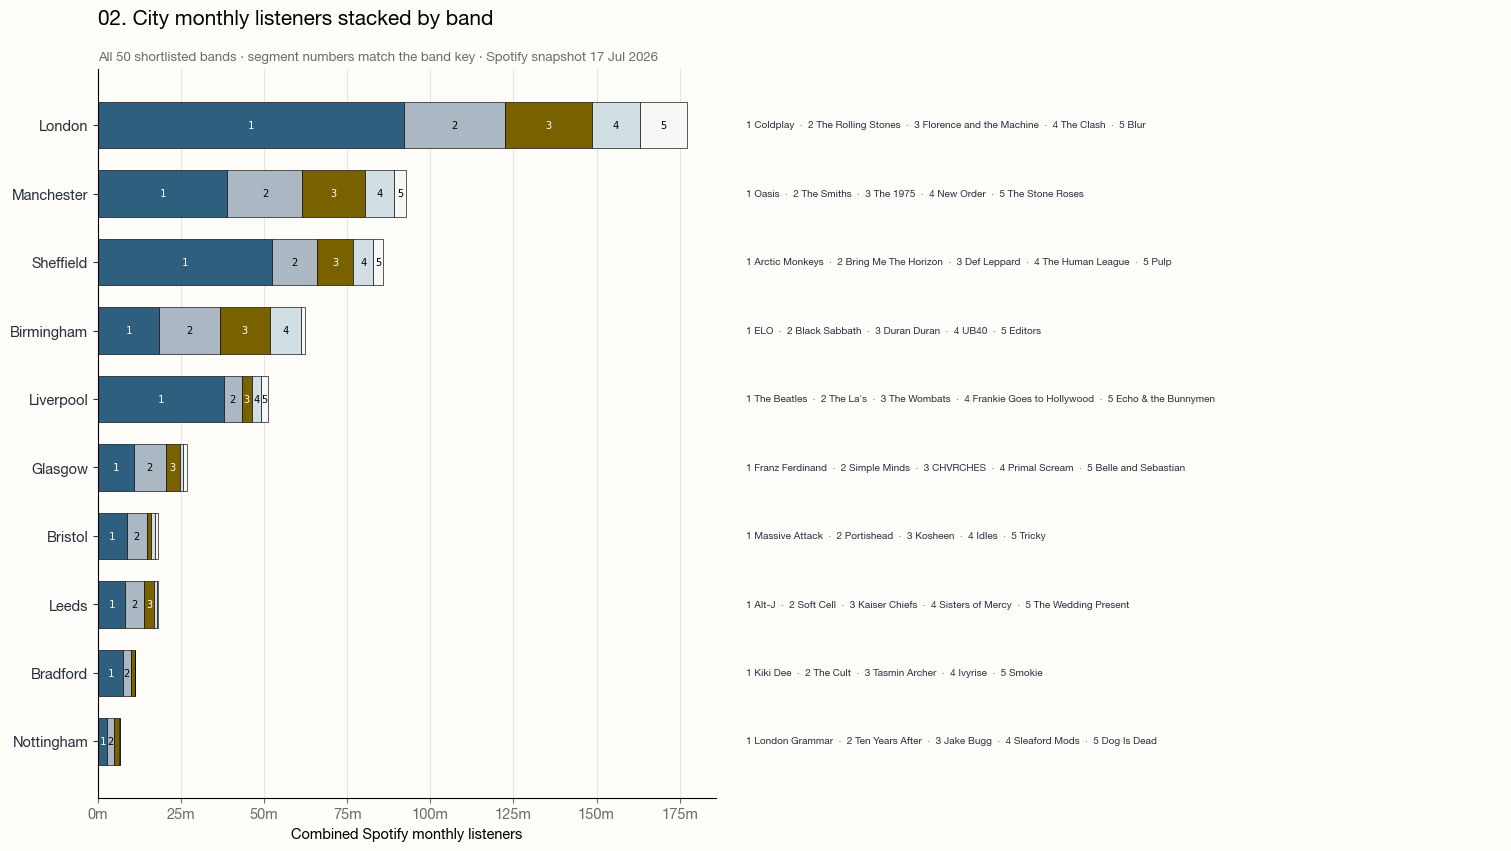

PosixPath('artifacts/publication_previews/20260717T225913Z/chart_02_city_band_stack.png')

In [6]:
# Split each city total into its five selected bands.
figure_02_path = plot_city_band_stack(
    band_data,
    snapshot_date=band_data["stats_extracted_at"].max().strftime("%d %b %Y"),
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_02_path)


### 06.03 Bands ranked by followers

Coldplay has the most followers in the shortlist, with 64,720,341. Arctic Monkeys and The Beatles rank next. This figure covers the selected 50 bands rather than all British artists on Spotify.


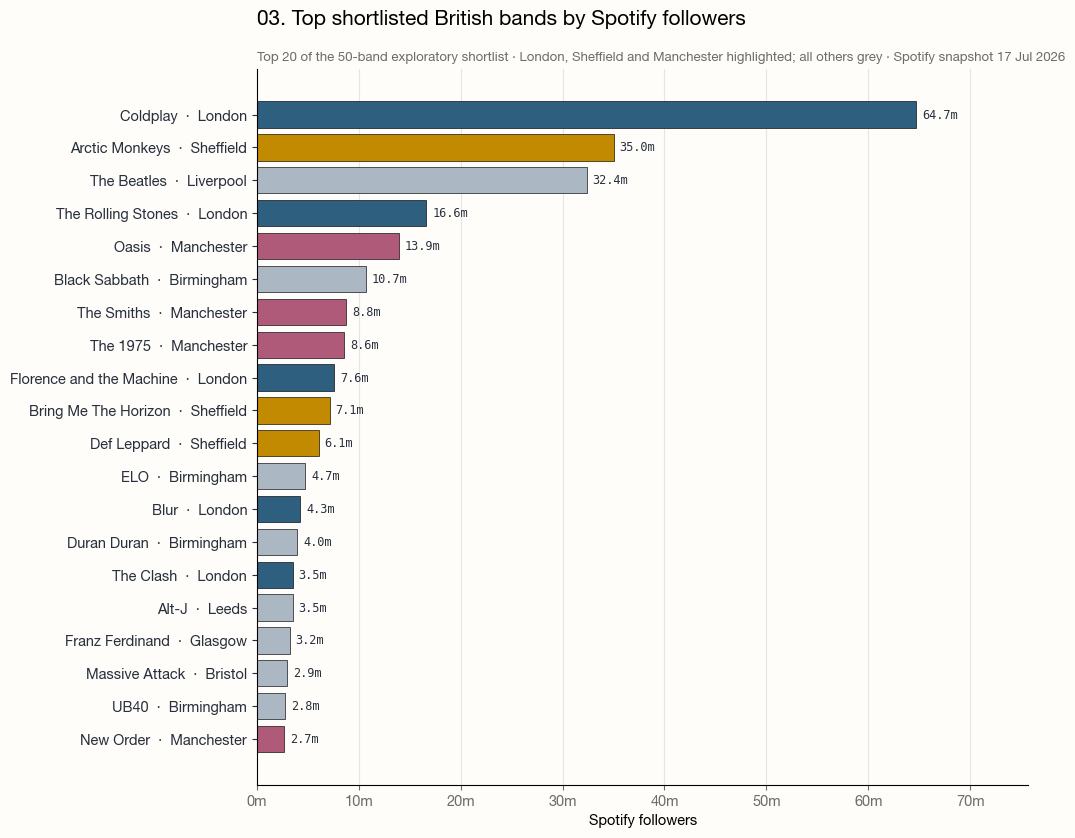

PosixPath('artifacts/publication_previews/20260717T225913Z/chart_03_top_bands_by_followers.png')

In [7]:
# Rank the top 20 shortlisted bands by Spotify followers.
highlighted_cities = ['London', 'Sheffield', 'Manchester']
figure_03_path = plot_top_bands_by_followers(
    band_data,
    snapshot_date=band_data["stats_extracted_at"].max().strftime("%d %b %Y"),
    highlighted_cities=highlighted_cities,
    top_n=20,
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_03_path)


## 07. Effect of population adjustment

The next comparison divides each five-band monthly-listener total by built-up-area population. The bands and Spotify measures remain unchanged.

Bristol moves from rank 7 to 4. London moves from 1 to 6. Sheffield ranks first after adjustment.

The ratio compares global Spotify reach with city size. It does not estimate listening by local residents.


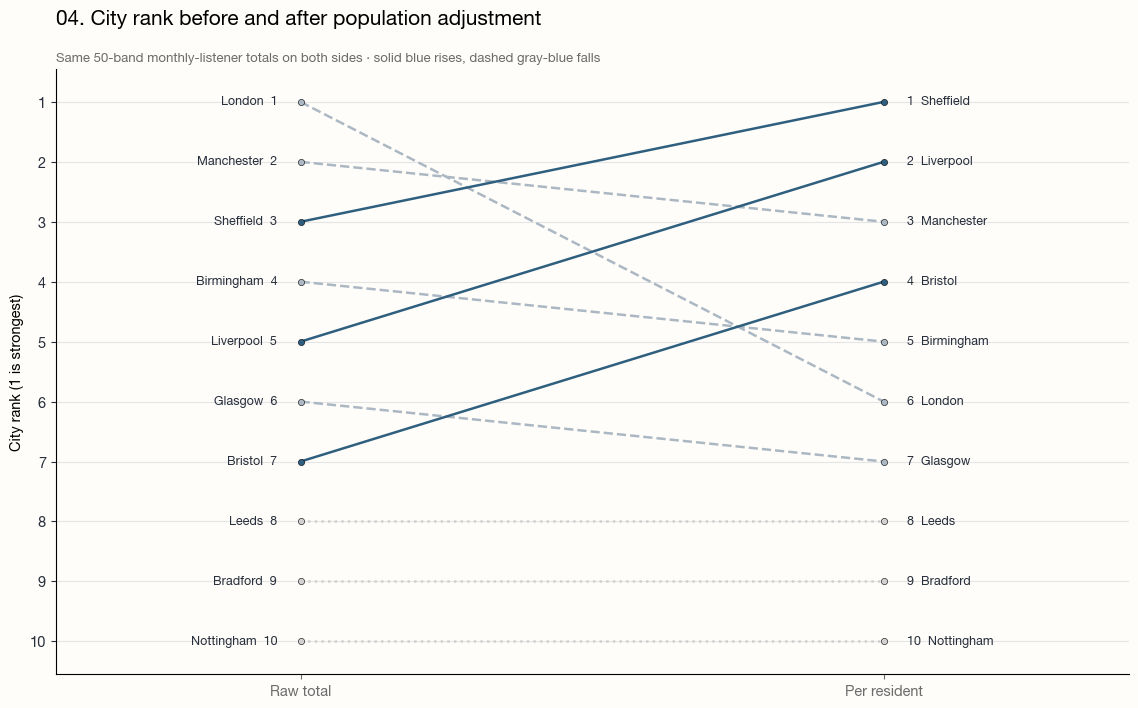

PosixPath('artifacts/publication_previews/20260717T225913Z/chart_04_population_rank_shift.png')

In [8]:
# Show how each city moves when population is added to the denominator.
figure_04_path = plot_population_rank_shift(
    all_band_city_rankings,
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_04_path)


## 08. Preferred scoring method

The preferred score includes bands with at least 100,000 followers, selects the three largest eligible bands in each city, sums their monthly listeners and divides the result by built-up-area population.

The threshold limits the influence of very small accounts and the top-three rule requires more than one successful band. Neither rule validates artist identity or corrects omissions from the shortlist.


In [9]:
# Apply the follower threshold and calculate the two preferred rankings.
FOLLOWER_THRESHOLD = 100_000
TOP_N = 3

eligible_bands = band_data.loc[band_data["followers"] >= FOLLOWER_THRESHOLD].copy()
monthly_rankings = build_city_rankings(
    eligible_bands,
    metric="monthly_listeners",
    top_n=TOP_N,
)
follower_rankings = build_city_rankings(
    eligible_bands,
    metric="followers",
    top_n=TOP_N,
)

rank_comparison = (
    monthly_rankings[["city", "rank"]]
    .rename(columns={"rank": "monthly_listener_rank"})
    .merge(
        follower_rankings[["city", "rank"]].rename(columns={"rank": "follower_rank"}),
        on="city",
        validate="one_to_one",
    )
)
rank_correlation = rank_comparison["monthly_listener_rank"].corr(
    rank_comparison["follower_rank"]
)

run_summary = pd.DataFrame(
    {
        "metric": ["Shortlisted bands", "Eligible bands", "Cities", "Rank correlation"],
        "value": [
            len(band_data),
            len(eligible_bands),
            len(monthly_rankings),
            f"{rank_correlation:.2f}",
        ],
    }
)
display(run_summary)


,metric,value
0,Shortlisted bands,50
1,Eligible bands,45
2,Cities,10
3,Rank correlation,0.93


### 08.01 Follower-threshold coverage

7 cities retain all five shortlisted bands. Reduced coverage is Leeds (4), Nottingham (4) and Bradford (2). Bradford retains only The Cult, so its preferred score does not represent a three-band catalogue.


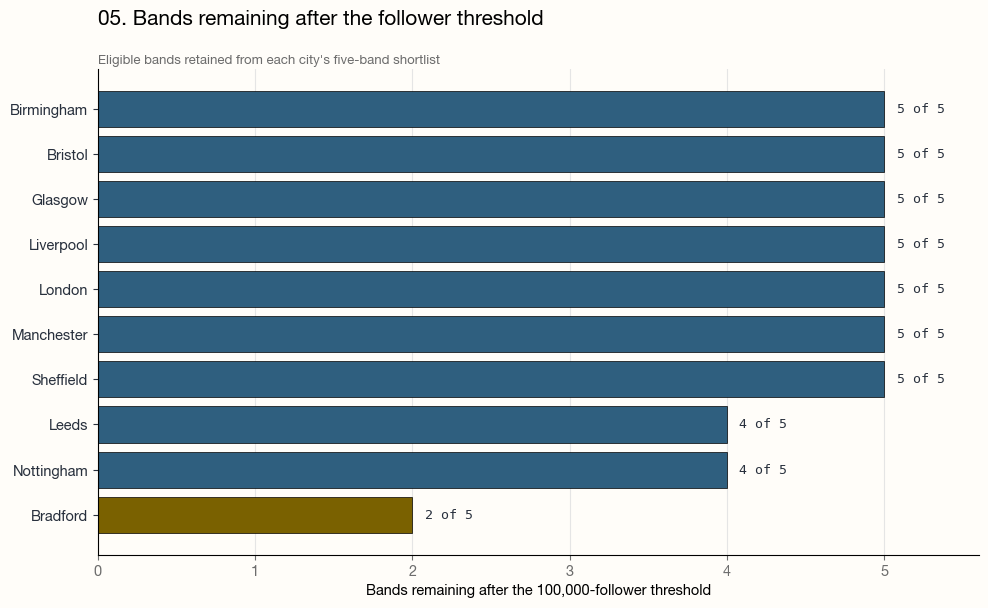

PosixPath('artifacts/publication_previews/20260717T225913Z/chart_05_threshold_coverage.png')

In [10]:
# Show how much of each five-band shortlist survives the threshold.
figure_05_path = plot_threshold_coverage(
    band_data,
    eligible_bands,
    follower_threshold=FOLLOWER_THRESHOLD,
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_05_path)


## 09. Population-adjusted city ranking

Sheffield's top three eligible bands have 76.8 million monthly listeners. The built-up-area population is 1.569 million. Dividing these values gives a reach-to-population ratio of 48.9.

The ratio is used to rank cities of different sizes. It is not a per-resident listening rate.


In [11]:
# Display the preferred ranking with enough context to audit it.
preferred_ranking_table = monthly_rankings[[
    "rank",
    "city",
    "top_n_ratio",
    "top_band",
    "eligible_bands",
]].rename(
    columns={
        "rank": "Rank",
        "city": "City",
        "top_n_ratio": "Top-three reach / population",
        "top_band": "Leading band",
        "eligible_bands": "Eligible bands",
    }
)

display(preferred_ranking_table)


,Rank,City,Top-three reach / population,Leading band,Eligible bands
0,1,Sheffield,48.947382,Arctic Monkeys,5
1,2,Liverpool,30.343589,The Beatles,5
2,3,Manchester,28.031267,Oasis,5
3,4,Bristol,22.557216,Massive Attack,5
4,5,Birmingham,19.865635,ELO,5
5,6,London,15.564497,Coldplay,5
6,7,Glasgow,14.695096,Franz Ferdinand,5
7,8,Leeds,8.882929,Alt-J,4
8,9,Bradford,7.137486,Kiki Dee,2
9,10,Nottingham,6.768081,London Grammar,4


### 09.01 Top-three monthly-listener ranking

Sheffield ranks first; the top three are Sheffield, Liverpool and Manchester. Its score is based on Arctic Monkeys, Bring Me The Horizon and Def Leppard.


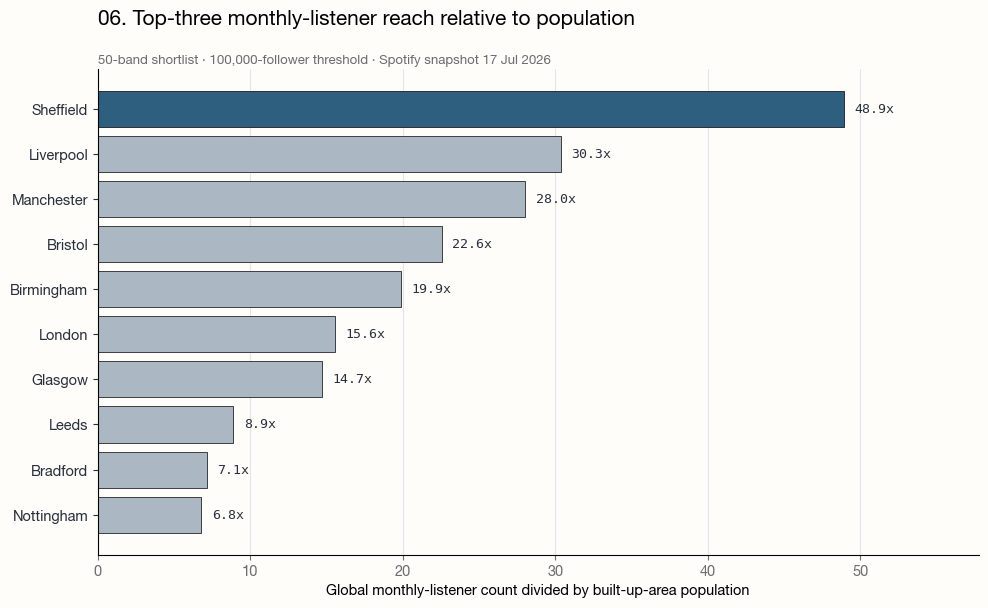

PosixPath('artifacts/publication_previews/20260717T225913Z/chart_06_top_three_monthly_listener_ratio.png')

In [12]:
# Plot the preferred top-three monthly-listener score.
figure_06_path = plot_top_three_ratio(
    monthly_rankings,
    snapshot_date=band_data["stats_extracted_at"].max().strftime("%d %b %Y"),
    follower_threshold=FOLLOWER_THRESHOLD,
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_06_path)


### 09.02 Monthly-listener and follower ranks

Sheffield, Liverpool and Manchester are the top three cities under monthly listeners. Sheffield, Liverpool and Manchester are the top three under followers. The rank correlation is 0.93. London and Birmingham change position, but the three leading cities remain the same.


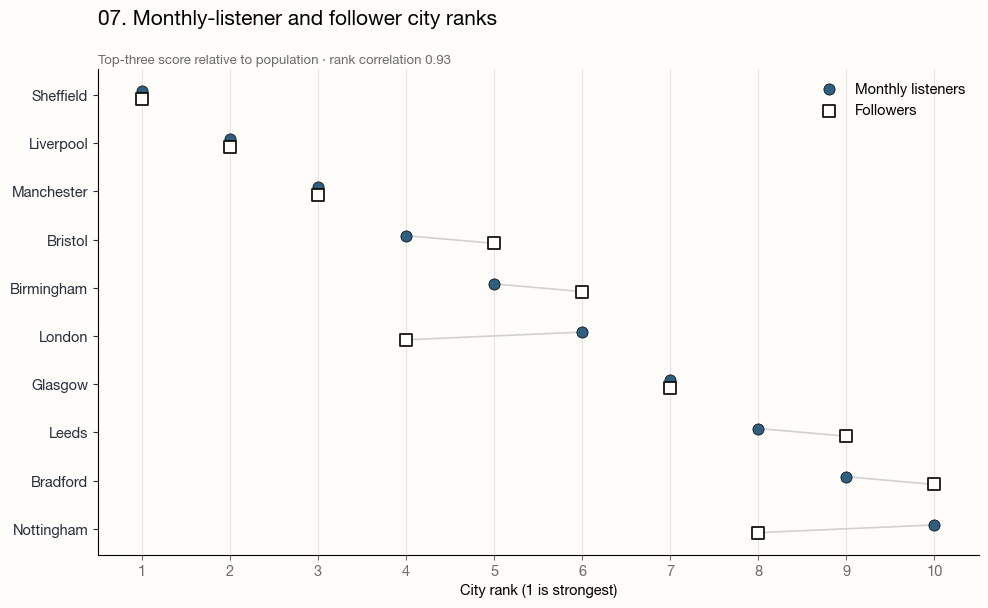

PosixPath('artifacts/publication_previews/20260717T225913Z/chart_07_metric_rank_comparison.png')

In [13]:
# Put monthly-listener and follower ranks on the same scale.
figure_07_path = plot_metric_rank_comparison(
    rank_comparison,
    rank_correlation,
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_07_path)


### 09.03 Leading-band concentration

The Beatles account for {facts['liverpool_concentration']:.0%} of Liverpool's eligible monthly listeners. Arctic Monkeys account for {facts['sheffield_concentration']:.0%} of Sheffield's. Manchester is less concentrated: its leading band accounts for {facts['manchester_concentration']:.0%}.

Bradford shows 100% because only The Cult remains above the follower threshold.


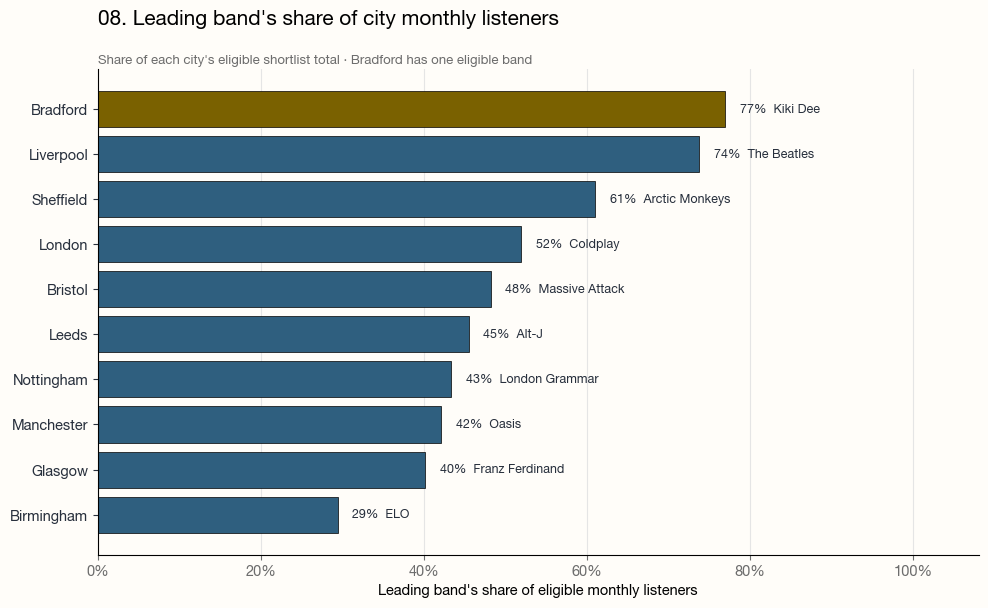

PosixPath('artifacts/publication_previews/20260717T225913Z/chart_08_top_band_concentration.png')

In [14]:
# Show the leading band's share of each eligible city total.
figure_08_path = plot_top_band_concentration(
    monthly_rankings,
    output_dir=CHART_OUTPUT_DIR,
)
display_path(figure_08_path)


## 10. Threshold sensitivity

The table recalculates the preferred ranking with no follower threshold and with thresholds of 100,000, 500,000 and one million.

The leading city is {facts['threshold_leaders'][0]} with no threshold, {facts['threshold_leaders'][100_000]} at 100,000 followers, {facts['threshold_leaders'][500_000]} at 500,000 and {facts['threshold_leaders'][1_000_000]} at one million. This test covers threshold choice only; it cannot account for bands omitted from the shortlist.


In [15]:
# Recalculate city rank across four follower thresholds.
sensitivity = build_threshold_sensitivity(
    band_data,
    thresholds=[0, 100_000, 500_000, 1_000_000],
    metric="monthly_listeners",
    top_n=TOP_N,
)
sensitivity_table = (
    sensitivity.pivot(index="city", columns="follower_threshold", values="rank")
    .rename(
        columns={
            0: "No threshold",
            100_000: "100k",
            500_000: "500k",
            1_000_000: "1m",
        }
    )
    .sort_values("100k")
    .reset_index()
    .rename(columns={"city": "City"})
)

display(sensitivity_table.fillna("Not eligible"))


follower_threshold,City,No threshold,100k,500k,1m
0,Sheffield,1.0,1.0,1.0,1.0
1,Liverpool,2.0,2.0,2.0,2.0
2,Manchester,3.0,3.0,3.0,3.0
3,Bristol,4.0,4.0,4.0,4.0
4,Birmingham,5.0,5.0,5.0,5.0
5,London,6.0,6.0,6.0,6.0
6,Glasgow,7.0,7.0,7.0,7.0
7,Leeds,8.0,8.0,8.0,8.0
8,Bradford,9.0,9.0,10.0,Not eligible
9,Nottingham,10.0,10.0,9.0,9.0


## 11. Conclusions and limitations

London has the largest unadjusted monthly-listener total in the shortlist. Population adjustment puts Sheffield first. Under the preferred top-three score, Sheffield, Liverpool and Manchester lead with either monthly listeners or followers.

The result applies only to the selected 50 bands. The shortlist is subjective, excludes solo artists and does not cover the whole United Kingdom. The Spotify snapshot is dated 17 July 2026, the metrics came from Spotify's public artist pages and at least one artist match is incorrect.

A national comparison would need the broader MusicBrainz catalogue, a manual review of band eligibility and origin, corrected Spotify identities and refreshed metrics.
